# ISL1 DE core gene validation

Validate whether NW's cardiac/ISL1-associated genes are present in the exported ISL1 limma DE tables and whether they pass the DE thresholds used in `02_DE_testing_ISL1_data_03142026.Rmd`.

## Setup

`NKX2.5` is normalized to the HGNC symbol `NKX2-5` before matching against the DE result tables. The repeated `IRX4` entry is de-duplicated.

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(ggplot2)
})

theme_set(theme_classic(base_size = 12))

personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
publication_dir <- file.path(personal_path, "publication")
output_dir <- file.path(publication_dir, "DE_core_genes_ISL1")

target_gene <- "ISL1"
cohort_order <- c("JAX", "MSK", "UCSF", "NW", "NW_parent")
fdr_cutoff <- 0.05
logfc_cutoff <- 1

dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
stopifnot(dir.exists(publication_dir))

publication_dir
output_dir

[1] "/fh/working/sun_w/sshen/MorPhiC/publication"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1"

## Core genes to check

In [2]:
core_gene_input <- c("NPPA",
                      "NPPB",
                      "ANKRD1",
                      "PPP1R12B",
                      "MYL4",
                      "MYL7",
                      "ACTA2",
                      "TNNT2",
                      "S100A10",
                      "CMYA5",
                      "MEF2C",
                      "NKX2-5")

core_gene_lookup <- tibble(query_gene = core_gene_input) %>%
  mutate(
    canonical_gene = recode(query_gene, "NKX2.5" = "NKX2-5"),
    gene_key = str_to_upper(canonical_gene)
  ) %>%
  distinct(gene_key, .keep_all = TRUE)

core_gene_lookup

query_gene,canonical_gene,gene_key
<chr>,<chr>,<chr>
NPPA,NPPA,NPPA
NPPB,NPPB,NPPB
ANKRD1,ANKRD1,ANKRD1
PPP1R12B,PPP1R12B,PPP1R12B
MYL4,MYL4,MYL4
MYL7,MYL7,MYL7
ACTA2,ACTA2,ACTA2
TNNT2,TNNT2,TNNT2
S100A10,S100A10,S100A10


## Load ISL1 DE result tables

In [3]:
de_file_index <- tibble(cohort = cohort_order) %>%
  mutate(
    file_name = paste0(target_gene, "_DE_", cohort, ".csv"),
    file = file.path(publication_dir, file_name),
    file_exists = file.exists(file)
  )

de_file_index
stopifnot(all(de_file_index$file_exists))

cohort,file_name,file,file_exists
<chr>,<chr>,<chr>,<lgl>
JAX,ISL1_DE_JAX.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_JAX.csv,TRUE
MSK,ISL1_DE_MSK.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_MSK.csv,TRUE
UCSF,ISL1_DE_UCSF.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_UCSF.csv,TRUE
NW,ISL1_DE_NW.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_NW.csv,TRUE
NW_parent,ISL1_DE_NW_parent.csv,/fh/working/sun_w/sshen/MorPhiC/publication/ISL1_DE_NW_parent.csv,TRUE


In [4]:
read_de_table <- function(file, cohort) {
  dt <- data.table::fread(file, data.table = FALSE)
  expected_cols <- c("logFC", "AveExpr", "t", "P.Value", "adj.P.Val", "B")
  
  if (!"gene_symbol" %in% names(dt)) {
    if ("V1" %in% names(dt)) {
      names(dt)[names(dt) == "V1"] <- "gene_symbol"
    } else {
      possible_symbol_cols <- setdiff(names(dt), expected_cols)
      if (length(possible_symbol_cols) == 0) {
        stop("Could not identify gene symbol column in ", file)
      }
      names(dt)[names(dt) == possible_symbol_cols[1]] <- "gene_symbol"
    }
  }
  
  missing_cols <- setdiff(c("gene_symbol", expected_cols), names(dt))
  if (length(missing_cols) > 0) {
    stop("Missing columns in ", file, ": ", paste(missing_cols, collapse = ", "))
  }
  
  dt %>%
    transmute(
      target_gene = target_gene,
      cohort = cohort,
      gene_symbol = as.character(gene_symbol),
      gene_key = str_to_upper(gene_symbol),
      logFC = as.numeric(logFC),
      AveExpr = as.numeric(AveExpr),
      t = as.numeric(t),
      P.Value = as.numeric(P.Value),
      adj.P.Val = as.numeric(adj.P.Val),
      B = as.numeric(B),
      source_file = basename(file)
    ) %>%
    arrange(adj.P.Val) %>%
    mutate(
      rank_by_adj_p = row_number(),
      rank_by_abs_logFC = min_rank(desc(abs(logFC))),
      is_DE = adj.P.Val < fdr_cutoff & abs(logFC) >= logfc_cutoff,
      DE_direction = case_when(
        is_DE & logFC > 0 ~ "up",
        is_DE & logFC < 0 ~ "down",
        TRUE ~ "not_DE"
      ),
      neg_log10_adj_p = -log10(pmax(adj.P.Val, .Machine$double.xmin))
    )
}

de_results <- purrr::map2_dfr(de_file_index$file, de_file_index$cohort, read_de_table) %>%
  mutate(cohort = factor(cohort, levels = cohort_order, ordered = TRUE))

de_results %>% count(cohort, name = "n_genes_tested")

Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 6 column names but the data has 7 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() af

cohort,n_genes_tested
<ord>,<int>
JAX,23332
MSK,22973
UCSF,23177
NW,23177
NW_parent,23171


## Validate presence and DE status

In [5]:
core_gene_presence <- tidyr::expand_grid(
  core_gene_lookup,
  cohort = factor(cohort_order, levels = cohort_order, ordered = TRUE)
) %>%
  left_join(
    de_results,
    by = c("gene_key", "cohort")
  ) %>%
  mutate(
    tested_in_DE_table = !is.na(gene_symbol),
    matched_gene_symbol = gene_symbol,
    is_DE = if_else(is.na(is_DE), FALSE, is_DE),
    DE_direction = if_else(is.na(DE_direction), "not_tested", DE_direction),
    signed_neg_log10_adj_p = if_else(
      tested_in_DE_table,
      sign(logFC) * neg_log10_adj_p,
      NA_real_
    )
  ) %>%
  select(
    query_gene,
    canonical_gene,
    cohort,
    tested_in_DE_table,
    matched_gene_symbol,
    logFC,
    adj.P.Val,
    P.Value,
    AveExpr,
    rank_by_adj_p,
    rank_by_abs_logFC,
    is_DE,
    DE_direction,
    signed_neg_log10_adj_p,
    source_file
  ) %>%
  arrange(match(canonical_gene, core_gene_lookup$canonical_gene), cohort)

core_gene_presence

query_gene,canonical_gene,cohort,tested_in_DE_table,matched_gene_symbol,logFC,adj.P.Val,P.Value,AveExpr,rank_by_adj_p,rank_by_abs_logFC,is_DE,DE_direction,signed_neg_log10_adj_p,source_file
<chr>,<chr>,<ord>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<lgl>,<chr>,<dbl>,<chr>
NPPA,NPPA,JAX,TRUE,NPPA,1.87438925,9.193047e-04,4.728123e-07,11.536205,12,784,TRUE,up,3.036540533,ISL1_DE_JAX.csv
NPPA,NPPA,MSK,TRUE,NPPA,2.24277103,1.117165e-02,1.585698e-05,11.738815,32,561,TRUE,up,1.951882723,ISL1_DE_MSK.csv
NPPA,NPPA,UCSF,TRUE,NPPA,0.97917432,1.827114e-07,2.467475e-09,11.314181,313,2408,FALSE,not_DE,6.738234361,ISL1_DE_UCSF.csv
NPPA,NPPA,NW,TRUE,NPPA,0.99846456,1.051506e-01,1.733078e-03,11.688890,382,3018,FALSE,not_DE,0.978188142,ISL1_DE_NW.csv
NPPA,NPPA,NW_parent,TRUE,NPPA,1.01220065,1.047554e-01,1.772220e-03,11.677290,392,2554,FALSE,not_DE,0.979823661,ISL1_DE_NW_parent.csv
NPPB,NPPB,JAX,TRUE,NPPB,1.58214658,2.285660e-01,2.163706e-02,8.038875,2211,1258,FALSE,not_DE,0.640988412,ISL1_DE_JAX.csv
NPPB,NPPB,MSK,TRUE,NPPB,3.34406900,4.778096e-02,3.478313e-04,9.175635,167,129,TRUE,up,1.320745119,ISL1_DE_MSK.csv
NPPB,NPPB,UCSF,TRUE,NPPB,0.92146387,1.002653e-06,2.400969e-08,9.582546,555,2690,FALSE,not_DE,5.998849282,ISL1_DE_UCSF.csv
NPPB,NPPB,NW,TRUE,NPPB,0.88012671,1.849423e-01,1.159712e-02,7.777554,1454,3744,FALSE,not_DE,0.732963773,ISL1_DE_NW.csv


In [6]:
core_gene_summary <- core_gene_presence %>%
  group_by(query_gene, canonical_gene) %>%
  summarise(
    tested_cohorts = paste(cohort[tested_in_DE_table], collapse = ", "),
    DE_cohorts = paste(cohort[is_DE], collapse = ", "),
    up_cohorts = paste(cohort[DE_direction == "up"], collapse = ", "),
    down_cohorts = paste(cohort[DE_direction == "down"], collapse = ", "),
    min_adj.P.Val = suppressWarnings(min(adj.P.Val, na.rm = TRUE)),
    max_abs_logFC = suppressWarnings(max(abs(logFC), na.rm = TRUE)),
    .groups = "drop"
  ) %>%
  mutate(
    across(c(tested_cohorts, DE_cohorts, up_cohorts, down_cohorts), ~ if_else(.x == "", "none", .x)),
    min_adj.P.Val = if_else(is.infinite(min_adj.P.Val), NA_real_, min_adj.P.Val),
    max_abs_logFC = if_else(is.infinite(max_abs_logFC), NA_real_, max_abs_logFC)
  )

core_gene_summary

query_gene,canonical_gene,tested_cohorts,DE_cohorts,up_cohorts,down_cohorts,min_adj.P.Val,max_abs_logFC
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
ACTA2,ACTA2,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,7.022228e-06,0.6413556
ANKRD1,ANKRD1,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,2.248001e-01,0.7876427
CMYA5,CMYA5,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,3.907466e-04,0.6899661
MEF2C,MEF2C,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,1.669529e-01,0.3696345
MYL4,MYL4,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,3.719230e-01,0.7792344
MYL7,MYL7,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,1.602053e-01,0.5419036
NKX2-5,NKX2-5,"JAX, MSK, UCSF, NW, NW_parent",none,none,none,5.419197e-04,0.5345832
NPPA,NPPA,"JAX, MSK, UCSF, NW, NW_parent","JAX, MSK","JAX, MSK",none,1.827114e-07,2.2427710
NPPB,NPPB,"JAX, MSK, UCSF, NW, NW_parent",MSK,MSK,none,1.002653e-06,3.3440690


## Export tables

In [7]:
presence_output_file <- file.path(output_dir, "ISL1_core_gene_DE_presence.tsv")
summary_output_file <- file.path(output_dir, "ISL1_core_gene_DE_summary.tsv")

data.table::fwrite(core_gene_presence, presence_output_file, sep = "\t")
data.table::fwrite(core_gene_summary, summary_output_file, sep = "\t")

presence_output_file
summary_output_file

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_presence.tsv"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_summary.tsv"

## Plot DE signal across cohorts

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_core_genes_ISL1/ISL1_core_gene_DE_dotplot.png"

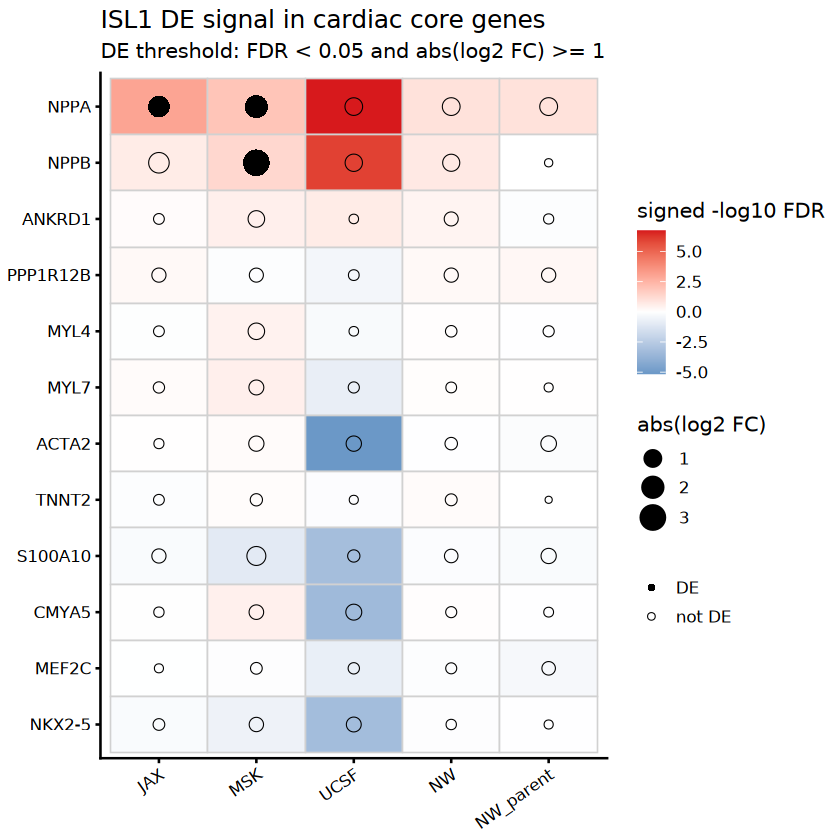

In [8]:
plot_df <- core_gene_presence %>%
  mutate(
    canonical_gene = factor(canonical_gene, levels = rev(core_gene_lookup$canonical_gene)),
    cohort = factor(cohort, levels = cohort_order, ordered = TRUE),
    is_DE_label = if_else(is_DE, "DE", "not DE")
  )

core_gene_plot <- ggplot(plot_df, aes(x = cohort, y = canonical_gene)) +
  geom_tile(aes(fill = signed_neg_log10_adj_p), color = "grey82", linewidth = 0.35) +
  geom_point(aes(size = abs(logFC), shape = is_DE_label), color = "black", stroke = 0.35, na.rm = TRUE) +
  scale_fill_gradient2(
    low = "#2C7BB6",
    mid = "white",
    high = "#D7191C",
    midpoint = 0,
    na.value = "grey92",
    name = "signed -log10 FDR"
  ) +
  scale_size_continuous(range = c(1.5, 7), name = "abs(log2 FC)") +
  scale_shape_manual(values = c("not DE" = 1, "DE" = 16), name = NULL) +
  labs(
    title = "ISL1 DE signal in cardiac core genes",
    subtitle = paste0("DE threshold: FDR < ", fdr_cutoff, " and abs(log2 FC) >= ", logfc_cutoff),
    x = NULL,
    y = NULL
  ) +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1),
    panel.grid = element_blank(),
    legend.position = "right"
  )

plot_output_file <- file.path(output_dir, "ISL1_core_gene_DE_dotplot.png")
ggsave(plot_output_file, core_gene_plot, width = 7, height = 3.6, dpi = 300)

core_gene_plot
plot_output_file

## Significant core-gene hits only

In [ ]:
core_gene_presence %>%
  filter(is_DE) %>%
  arrange(canonical_gene, cohort) %>%
  select(canonical_gene, cohort, logFC, adj.P.Val, DE_direction, rank_by_adj_p, source_file)